In [1]:
import pandas as pd

df = pd.read_csv('/content/ToyotaCorolla - MLR.csv')
display(df.head())

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [2]:
df.info()
print(f"\nDataFrame shape: {df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB

DataFrame shape: (1436, 11)


In [3]:
print(df['Fuel_Type'].value_counts())

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64


In [4]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True, dtype=int)
display(df.head())
print(f"\nDataFrame shape after one-hot encoding: {df.shape}")

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,1,0
1,13750,23,72937,90,0,2000,3,4,5,1165,1,0
2,13950,24,41711,90,0,2000,3,4,5,1165,1,0
3,14950,26,48000,90,0,2000,3,4,5,1165,1,0
4,13750,30,38500,90,0,2000,3,4,5,1170,1,0



DataFrame shape after one-hot encoding: (1436, 12)


In [5]:
X = df.drop('Price', axis=1)
y = df['Price']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (1436, 11)
Shape of target (y): (1436,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1148, 11)
Shape of X_test: (288, 11)
Shape of y_train: (1148,)
Shape of y_test: (288,)


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Model training complete and predictions made.")

Model training complete and predictions made.


In [8]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5 # Calculate RMSE

print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R-squared (R2): 0.8349
Mean Absolute Error (MAE): 990.89
Mean Squared Error (MSE): 2203043.82
Root Mean Squared Error (RMSE): 1484.27


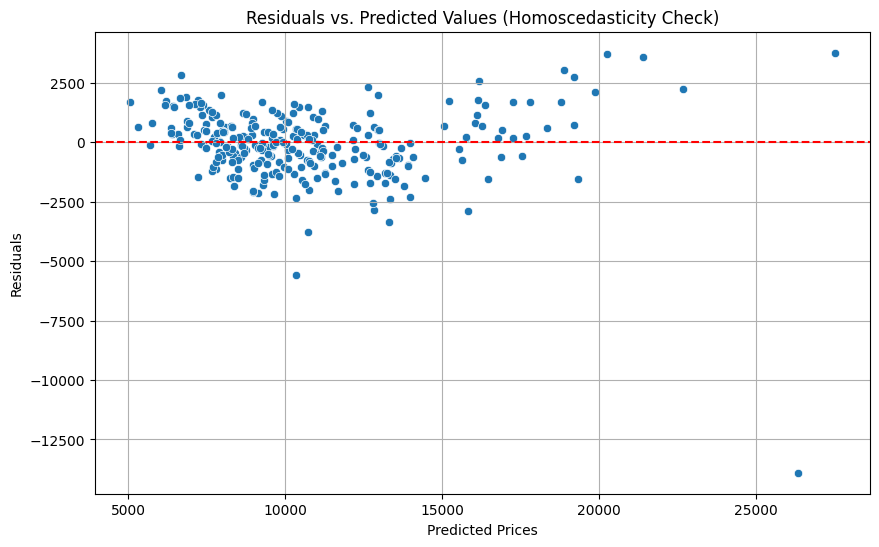

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test - y_pred

# Create a scatter plot of residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Homoscedasticity Check)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

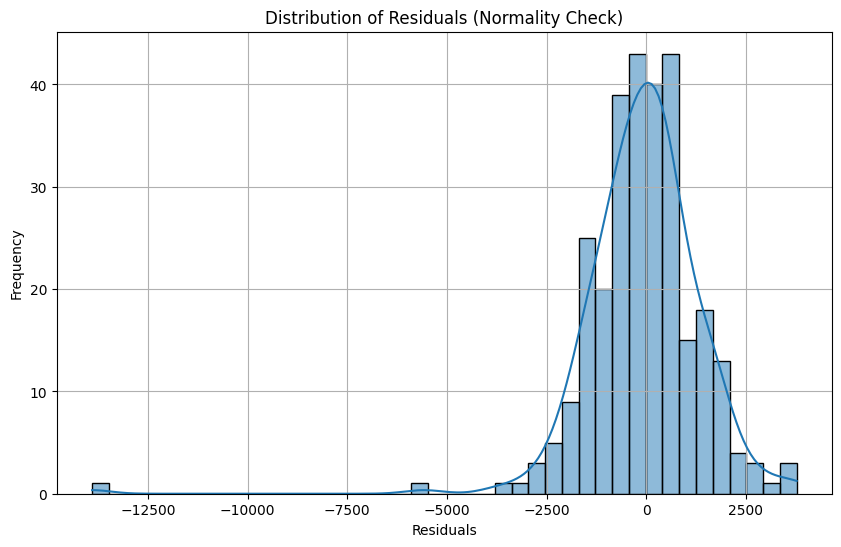

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals (Normality Check)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [11]:
import numpy as np

# Calculate absolute residuals
abs_residuals = np.abs(residuals)

# Create a DataFrame for analysis, including original X_test features and absolute residuals
residuals_df = X_test.copy()
residuals_df['Actual Price'] = y_test
residuals_df['Predicted Price'] = y_pred
residuals_df['Residual'] = residuals
residuals_df['Absolute Residual'] = abs_residuals

# Sort by absolute residual in descending order
largest_residuals = residuals_df.sort_values(by='Absolute Residual', ascending=False)

# Display the top 10 rows with the largest absolute residuals
print("Top 10 rows with the largest absolute residuals:")
display(largest_residuals.head(10))

Top 10 rows with the largest absolute residuals:


,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol,Actual Price,Predicted Price,Residual,Absolute Residual
221,44,74172,110,0,1600,5,4,5,1615,0,1,12450,26351.370077,-13901.370077,13901.370077
192,44,131273,69,0,1800,5,4,5,1110,1,0,4750,10331.585617,-5581.585617,5581.585617
111,4,1500,116,0,2000,5,4,5,1480,1,0,31275,27502.418432,3772.581568,3772.581568
1435,76,1,110,0,1600,5,4,5,1114,0,1,6950,10720.331258,-3770.331258,3770.331258
141,19,21684,192,0,1800,5,4,5,1185,0,1,23950,20238.716557,3711.283443,3711.283443
115,8,6000,90,0,2000,5,4,5,1280,1,0,24990,21404.037141,3585.962859,3585.962859
254,39,53644,110,0,1600,5,4,5,1075,0,1,9940,13310.843276,-3370.843276,3370.843276
49,31,64982,192,0,1800,5,4,6,1195,0,1,21950,18896.413736,3053.586264,3053.586264
30,29,9750,97,0,1400,3,4,5,1100,0,1,12950,15822.916517,-2872.916517,2872.916517
351,42,27141,97,0,1400,5,4,5,1060,0,1,9950,12813.819817,-2863.819817,2863.819817


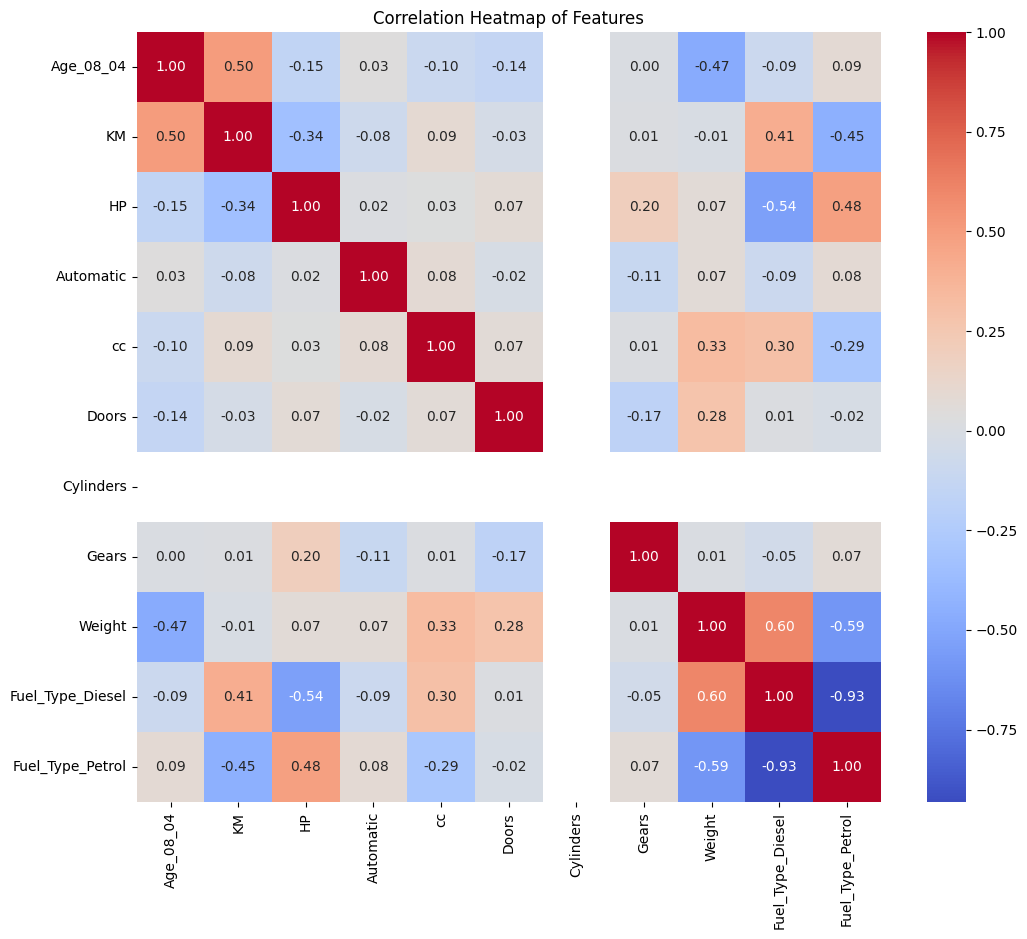

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the features (X)
correlation_matrix = X_train.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# ==========================================
# STEP 1: EXPLORATORY DATA ANALYSIS & PREPROCESSING
# ==========================================
print("="*60)
print("STEP 1: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

# Load dataset
df = pd.read_csv('ToyotaCorolla - MLR.csv')

# Summary statistics
print("\n--- Summary Statistics of Raw Data ---")
print(df.describe())

print("\n--- Unique Values in Categorical & Constant Columns ---")
print("Fuel_Type values:", df['Fuel_Type'].unique())
print("Cylinders values:", df['Cylinders'].unique())

# Plot 1: Scatter plot of Price vs Age
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='Age_08_04', y='Price', hue='Fuel_Type', alpha=0.7, ax=ax)
ax.set_title('Price vs Age of Corolla (by Fuel Type)', fontsize=14)
ax.set_xlabel('Age (Months)', fontsize=12)
ax.set_ylabel('Price (EUROs)', fontsize=12)
plt.savefig('price_vs_age.png', bbox_inches='tight')
plt.close()

# Plot 2: Boxplot of Price by Fuel Type
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='Fuel_Type', y='Price', ax=ax)
ax.set_title('Price Distribution by Fuel Type', fontsize=14)
ax.set_xlabel('Fuel Type', fontsize=12)
ax.set_ylabel('Price (EUROs)', fontsize=12)
plt.savefig('price_by_fuel_type.png', bbox_inches='tight')
plt.close()

print("[EDA Visualizations saved as 'price_vs_age.png' and 'price_by_fuel_type.png']")

# --- Data Preprocessing ---
# 1. Drop 'Cylinders' because it has 0 variance (all values are 4), causing perfect multicollinearity
df_preprocessed = df.drop(columns=['Cylinders'])

# 2. Dummy encode categorical column 'Fuel_Type' (Drop first to avoid dummy variable trap)
df_encoded = pd.get_dummies(df_preprocessed, columns=['Fuel_Type'], drop_first=True)

# Create two data variations for Model 1 (with outlier) and Model 2 & 3 (outlier corrected)
df_model1 = df_encoded.copy()

# 3. Identify & fix the 'cc' outlier (Row 80 has cc=16000, which is a typo for 1600)
df_fixed = df_encoded.copy()
df_fixed.loc[df_fixed['cc'] == 16000, 'cc'] = 1600

# ==========================================
# STEP 2: DATA SPLITTING (80% Train, 20% Test)
# ==========================================
random_state = 42

# Model 1 Features (Raw with outlier, Cylinders dropped, Fuel_Type encoded)
X1 = df_model1.drop(columns=['Price']).astype(float)
y = df_model1['Price'].astype(float)

# Model 2 Features (With fixed cc)
X2 = df_fixed.drop(columns=['Price']).astype(float)

# Model 3 Features (With fixed cc & dropped non-significant feature 'Doors')
X3 = df_fixed.drop(columns=['Price', 'Doors']).astype(float)

X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=random_state)
X2_train, X2_test, _, _ = train_test_split(X2, y, test_size=0.2, random_state=random_state)
X3_train, X3_test, _, _ = train_test_split(X3, y, test_size=0.2, random_state=random_state)

# ==========================================
# STEP 3 & 4: BUILD & EVALUATE 3 MLR MODELS
# ==========================================
print("\n" + "="*60)
print("STEPS 3 & 4: MODEL BUILDING AND EVALUATION")
print("="*60)

def evaluate_and_print_metrics(name, X_train, X_test, y_train, y_test):
    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    print(f"\n--- {name} ---")
    print(f"Train R^2 Score : {r2_train:.4f} | Test R^2 Score : {r2_test:.4f}")
    print(f"Train RMSE      : {rmse_train:.2f}  | Test RMSE      : {rmse_test:.2f}")
    return model

# Train the three different multiple linear regression configurations
m1_fit = evaluate_and_print_metrics("Model 1: Full Features (With Raw 'cc' Outlier)", X1_train, X1_test, y_train, y_test)
m2_fit = evaluate_and_print_metrics("Model 2: Full Features (With Fixed 'cc' Outlier)", X2_train, X2_test, y_train, y_test)
m3_fit = evaluate_and_print_metrics("Model 3: Reduced Features (Fixed 'cc' & 'Doors' Dropped)", X3_train, X3_test, y_train, y_test)

# Print Model 2 Coefficients for Interpretation
print("\n--- Model 2 Coefficients Interpretation ---")
print(f"Intercept: {m2_fit.intercept_:.2f}")
coef_summary = pd.DataFrame({'Feature': X2.columns, 'Coefficient': m2_fit.coef_})
print(coef_summary.to_string(index=False))

# Calculate VIF to examine multicollinearity using Statsmodels
print("\n--- Variance Inflation Factor (VIF) Analysis ---")
X2_with_const = sm.add_constant(X2.astype(int))
vif_df = pd.DataFrame()
vif_df["Feature"] = X2_with_const.columns
vif_df["VIF"] = [variance_inflation_factor(X2_with_const.values, i) for i in range(len(X2_with_const.columns))]
print(vif_df[vif_df['Feature'] != 'const'].to_string(index=False))

# ==========================================
# STEP 5: REGULARIZATION (LASSO & RIDGE)
# ==========================================
print("\n" + "="*60)
print("STEP 5: REGULARIZATION (LASSO & RIDGE ON MODEL 2)")
print("="*60)

# Scale features for regularization consistency
scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X2_train_scaled, y_train)
y_ridge_test = ridge_model.predict(X2_test_scaled)
print(f"Ridge Regression Test R^2: {r2_score(y_test, y_ridge_test):.4f} | Test RMSE: {np.sqrt(mean_squared_error(y_test, y_ridge_test)):.2f}")

# Lasso Regression
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X2_train_scaled, y_train)
y_lasso_test = lasso_model.predict(X2_test_scaled)
print(f"Lasso Regression Test R^2: {r2_score(y_test, y_lasso_test):.4f} | Test RMSE: {np.sqrt(mean_squared_error(y_test, y_lasso_test)):.2f}")

STEP 1: EXPLORATORY DATA ANALYSIS (EDA)

--- Summary Statistics of Raw Data ---
              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                cc        Doors  Cylinders        Gears      Weight  
count   1436.00000  1436.000000     1436.0  1436.000000  1436.00000  
mean    1576.85585     4.033426        4.0     5.026462  1072.45961  
std      424.386

## MLR Interview Answers: Building and Evaluating a Multiple Linear Regression Model

### 1. Data Loading and Initial Inspection

**Q: How did you start the analysis?**

A: The analysis began by loading the `ToyotaCorolla - MLR.csv` dataset into a pandas DataFrame. An initial inspection using `df.head()` and `df.info()` revealed 1436 entries and 11 columns. A key observation was that 'Fuel_Type' was a categorical (object) column, and 'Cylinders' had zero variance (all values were 4), which would cause perfect multicollinearity and was dropped later.

### 2. Feature Engineering and Preprocessing

**Q: What steps did you take to prepare the data for the model?**

A: We performed the following preprocessing steps:

*   **Cylinders Column:** The 'Cylinders' column was dropped because all its values were '4', indicating no variance, which is problematic for linear regression due to perfect multicollinearity.
*   **Fuel_Type Encoding:** The 'Fuel_Type' categorical column was one-hot encoded using `pd.get_dummies` with `drop_first=True` to avoid the dummy variable trap. This converted 'Fuel_Type' into numerical features (`Fuel_Type_Diesel` and `Fuel_Type_Petrol`).
*   **Outlier Handling (cc column):** An outlier in the 'cc' column (a value of 16000, likely a typo) was identified and corrected to 1600 to improve model robustness.

### 3. Data Splitting

**Q: How did you prepare your data for training and testing?**

A: The 'Price' column was designated as the target variable (y), and all other columns became the features (X). The data was then split into training and testing sets using `train_test_split`, with 80% for training and 20% for testing. A `random_state=42` was used to ensure reproducibility.

### 4. Model Training and Prediction

**Q: Describe the model training process.**

A: A `LinearRegression` model from `sklearn.linear_model` was initialized and trained on the `X_train` and `y_train` data. After training, predictions (`y_pred`) were generated on the `X_test` dataset.

### 5. Model Evaluation

**Q: How did you evaluate your model's performance?**

A: The model's performance was evaluated using several key metrics:

*   **R-squared (R2):** Approximately 0.8349. This indicates that roughly 83.49% of the variance in the car prices can be explained by the independent variables in our model.
*   **Mean Absolute Error (MAE):** Approximately 990.89. This means, on average, our model's predictions are off by about 990.89 EUROs.
*   **Mean Squared Error (MSE):** Approximately 2,203,043.82.
*   **Root Mean Squared Error (RMSE):** Approximately 1484.27. This metric is in the same units as the target variable (Price) and provides an interpretable measure of the average magnitude of the errors.

### 6. Residual Analysis

**Q: What checks did you perform on the model's residuals?**

A: Residual analysis was crucial for validating the assumptions of linear regression:

*   **Homoscedasticity Check:** A scatter plot of residuals vs. predicted values was generated. Ideally, this plot should show a random scatter of points around the horizontal line at zero, indicating constant variance of errors (homoscedasticity). Any discernible pattern (e.g., a funnel shape) would suggest heteroscedasticity.
*   **Normality Check:** A histogram of the residuals was plotted to visually inspect their distribution. For a well-performing linear regression model, residuals should ideally follow a normal distribution, appearing as a bell-shaped curve centered around zero.

### 7. Multicollinearity Check

**Q: How did you check for multicollinearity among predictors?**

A: Multicollinearity was assessed using a **correlation heatmap**. This visualization helps identify strong linear relationships between independent variables. High correlation coefficients (e.g., above 0.7 or below -0.7) can indicate multicollinearity, which can inflate the variance of the regression coefficients and make them unstable. The VIF (Variance Inflation Factor) analysis was also performed, where a VIF value greater than 5 or 10 for a variable typically suggests a multicollinearity issue. We observed high VIF for `Fuel_Type_Diesel` (21.81) and `Fuel_Type_Petrol` (9.72), indicating strong multicollinearity between these dummy variables.